# AnswerMap on Colab
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sanataff/AnswerMap/blob/main/demo.ipynb)

Where is the model looking? 16 yes/no questions, one map. Use **Runtime → Change runtime type → T4 GPU** (free).

In [1]:
!git clone -q https://github.com/sanataff/AnswerMap.git
%cd AnswerMap
!pip install -q -U "transformers>=4.57" accelerate

/content/AnswerMap
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 33.1 MB/s eta 0:00:00


In [2]:
import torch, requests
import matplotlib.pyplot as plt
from AnswerMap.answermap import Config, VLM, load_image, probe

gpu = torch.cuda.is_available()
cfg = Config(model_name="Qwen/Qwen3-VL-2B-Instruct",   # small model, fits a free T4
             device="cuda:0" if gpu else "cpu",
             dtype="bfloat16" if gpu and torch.cuda.get_device_capability()[0] >= 8 else "float32",
             max_side=512, min_pixels=3136)
vlm = VLM(cfg)

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.26GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

[vlm] enable_thinking has no effect on this template. Fine for a non-thinking model; on a THINKING model every probe would score the reasoning prefix -- verify before trusting results.


query: 'the remote control'
query: 'a person'


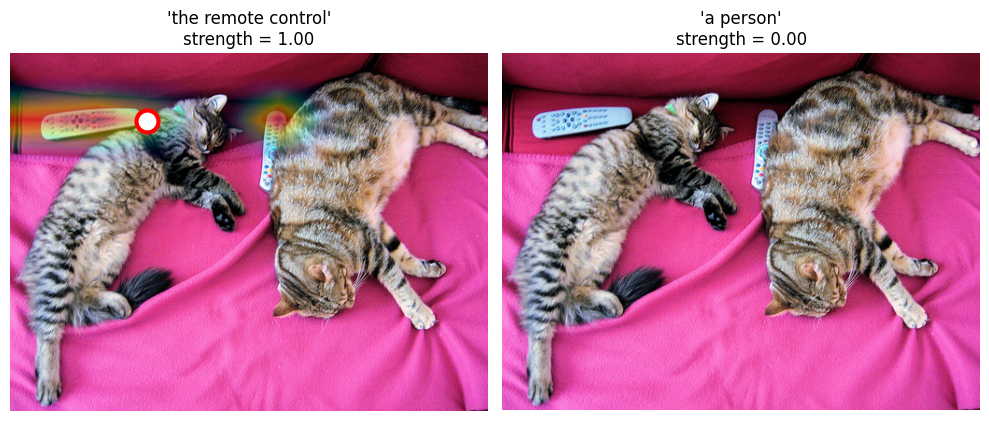

In [3]:
open("example.jpg", "wb").write(requests.get("http://images.cocodataset.org/val2017/000000039769.jpg").content)
# your own image: from google.colab import files; path = list(files.upload())[0]
img = load_image("example.jpg", 512)

def answermap(query, ax):
    r = probe(vlm, img, query, cfg)          # 8x8 grid = 16 yes/no forward passes
    M, W, H = r["M"], *img.size
    ax.imshow(img)
    ax.imshow(M, cmap="jet", vmin=0, vmax=1, alpha=0.6 * M, extent=(0, W, H, 0), interpolation="bilinear")
    if M.max() > 0.5:                        # pin = where the model locates the query
        ax.scatter(*r["point"], s=250, c="white", edgecolors="red", linewidths=3)
    ax.set_title(f"{query!r}\nstrength = {M.max():.2f}"); ax.axis("off")

queries = ["the remote control", "a person"]
fig, axes = plt.subplots(1, len(queries), figsize=(5 * len(queries), 4.5))
for q, ax in zip(queries, axes):
    answermap(q, ax)
plt.tight_layout(); plt.show()

**Strength** near 1 means the model sees the query; near 0 means it does not. Change `queries` or the image and rerun.